# Gap 3 — EWC INT8 vs FP32 : Validation fake-quantization

Ce notebook valide le critère Gap 3 : **AUROC_INT8 ≥ AUROC_FP32 − 0.02**.

Sources :
- `experiments/exp_S22_INT8_01/results/results.json` — CWRU
- `experiments/exp_S22_INT8_02/results/results.json` — CMAPSS

Référence : `docs/sprints/sprint_22/S2217_ewc_int8_python.md`

## 1. Chargement des résultats

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

ROOT = Path("..")

results_cwru   = json.loads((ROOT / "experiments/exp_S22_INT8_01/results/results.json").read_text())
results_cmapss = json.loads((ROOT / "experiments/exp_S22_INT8_02/results/results.json").read_text())

print("CWRU   :", results_cwru)
print("CMAPSS :", results_cmapss)

CWRU   : {'exp_id': 'exp_S22_INT8_01', 'dataset': 'cwru', 'fp32': {'auroc_final': 0.99984, 'acc_final': 1.0, 'avg_forgetting': 0.0, 'ram_peak_bytes': 1171}, 'int8': {'auroc_final': 0.99968, 'acc_final': 1.0, 'avg_forgetting': 0.0, 'ram_peak_bytes': 4714}, 'delta_auroc': 0.00016, 'gap3_criterion_met': True}
CMAPSS : {'exp_id': 'exp_S22_INT8_02', 'dataset': 'cmapss', 'fp32': {'auroc_final': 0.806192, 'acc_final': 0.914438, 'avg_forgetting': 0.000162, 'ram_peak_bytes': 1171}, 'int8': {'auroc_final': 0.803713, 'acc_final': 0.914594, 'avg_forgetting': 0.000809, 'ram_peak_bytes': 5511}, 'delta_auroc': 0.00248, 'gap3_criterion_met': True}


## 2. Tableau AUROC FP32 vs INT8

In [2]:
rows = []
for r, name in [(results_cwru, "CWRU"), (results_cmapss, "CMAPSS")]:
    auroc_fp32 = r["fp32"]["auroc_final"]
    auroc_int8 = r["int8"]["auroc_final"]
    delta      = r["delta_auroc"]
    gap3_ok    = r["gap3_criterion_met"]
    rows.append({
        "Dataset":    name,
        "AUROC FP32": f"{auroc_fp32:.4f}",
        "AUROC INT8": f"{auroc_int8:.4f}",
        "Δ AUROC":    f"{delta:.4f}",
        "Gap 3":      "✅" if gap3_ok else "❌",
    })

df = pd.DataFrame(rows)
df

,Dataset,AUROC FP32,AUROC INT8,Δ AUROC,Gap 3
0,CWRU,0.9998,0.9997,0.0002,✅
1,CMAPSS,0.8062,0.8037,0.0025,✅


## 3. Barplot comparatif AUROC

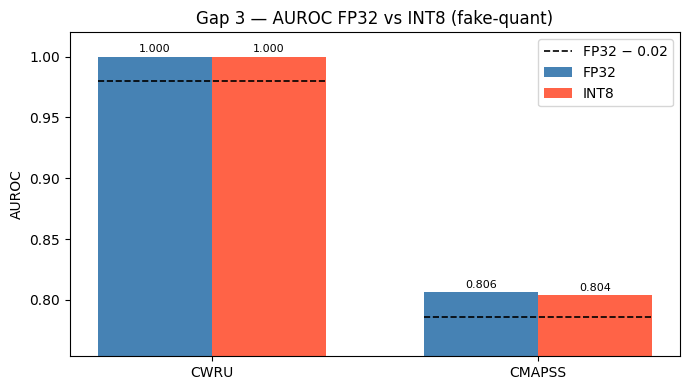

In [3]:
datasets  = ["CWRU", "CMAPSS"]
auroc_fp32 = [results_cwru["fp32"]["auroc_final"],   results_cmapss["fp32"]["auroc_final"]]
auroc_int8 = [results_cwru["int8"]["auroc_final"],   results_cmapss["int8"]["auroc_final"]]

x = np.arange(len(datasets))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
bars_fp32 = ax.bar(x - width / 2, auroc_fp32, width, label="FP32",  color="steelblue")
bars_int8 = ax.bar(x + width / 2, auroc_int8, width, label="INT8",  color="tomato")

# Ligne Δ = 0.02 sous FP32
for i, (fp, it) in enumerate(zip(auroc_fp32, auroc_int8)):
    threshold = fp - 0.02
    ax.hlines(threshold, i - width, i + width, colors="black", linestyles="dashed",
              linewidth=1.2, label="FP32 − 0.02" if i == 0 else "_nolegend_")

ax.set_xticks(x)
ax.set_xticklabels(datasets)
ax.set_ylabel("AUROC")
ax.set_title("Gap 3 — AUROC FP32 vs INT8 (fake-quant)")
ax.legend()
ax.set_ylim(max(0, min(auroc_int8) - 0.05), 1.02)
ax.bar_label(bars_fp32, fmt="%.3f", padding=2, fontsize=8)
ax.bar_label(bars_int8, fmt="%.3f", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/eda/gap3_auroc_fp32_vs_int8.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Courbes Average Forgetting FP32 vs INT8

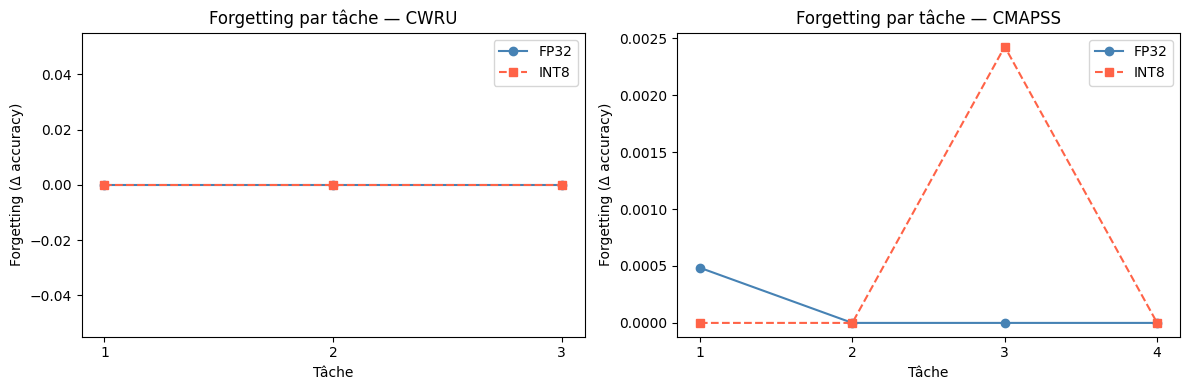

In [4]:
def load_acc_matrix(exp_dir: Path, model: str) -> np.ndarray | None:
    path = exp_dir / "results" / f"acc_matrix_{model}.npy"
    return np.load(path, allow_pickle=True) if path.exists() else None

def per_task_forgetting(acc_matrix: np.ndarray) -> np.ndarray:
    """Chute d'accuracy par tâche : max vu - valeur finale."""
    T = acc_matrix.shape[1]
    forgetting = []
    for j in range(T):
        col = acc_matrix[:, j]
        valid = col[~np.isnan(col)]
        if len(valid) < 2:
            forgetting.append(0.0)
        else:
            forgetting.append(float(valid.max() - valid[-1]))
    return np.array(forgetting)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (exp_name, exp_id, name) in zip(axes, [
    ("CWRU",   "exp_S22_INT8_01", "CWRU"),
    ("CMAPSS", "exp_S22_INT8_02", "CMAPSS"),
]):
    exp_dir = ROOT / "experiments" / exp_id
    mat_fp32 = load_acc_matrix(exp_dir, "fp32")
    mat_int8 = load_acc_matrix(exp_dir, "int8")

    if mat_fp32 is not None and mat_int8 is not None:
        fg_fp32 = per_task_forgetting(mat_fp32)
        fg_int8 = per_task_forgetting(mat_int8)
        tasks_x = np.arange(1, len(fg_fp32) + 1)
        ax.plot(tasks_x, fg_fp32, "o-", label="FP32", color="steelblue")
        ax.plot(tasks_x, fg_int8, "s--", label="INT8", color="tomato")
        ax.set_xlabel("Tâche")
        ax.set_ylabel("Forgetting (Δ accuracy)")
        ax.set_title(f"Forgetting par tâche — {name}")
        ax.legend()
        ax.set_xticks(tasks_x)
    else:
        ax.text(0.5, 0.5, f"Données manquantes\n{exp_id}", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(f"Forgetting — {name}")

plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/eda/gap3_forgetting_fp32_vs_int8.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Analyse mémoire FP32 vs INT8

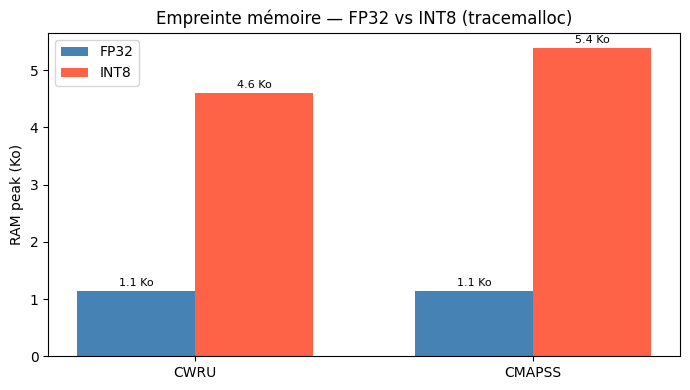

CWRU — FP32=1171 B | INT8=4714 B | ratio=0.2x
CMAPSS — FP32=1171 B | INT8=5511 B | ratio=0.2x


In [5]:
datasets_mem = ["CWRU", "CMAPSS"]
ram_fp32 = [results_cwru["fp32"]["ram_peak_bytes"], results_cmapss["fp32"]["ram_peak_bytes"]]
ram_int8 = [results_cwru["int8"]["ram_peak_bytes"], results_cmapss["int8"]["ram_peak_bytes"]]

x = np.arange(len(datasets_mem))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
b1 = ax.bar(x - width / 2, [r / 1024 for r in ram_fp32], width, label="FP32", color="steelblue")
b2 = ax.bar(x + width / 2, [r / 1024 for r in ram_int8], width, label="INT8", color="tomato")

ax.set_xticks(x)
ax.set_xticklabels(datasets_mem)
ax.set_ylabel("RAM peak (Ko)")
ax.set_title("Empreinte mémoire — FP32 vs INT8 (tracemalloc)")
ax.legend()
ax.bar_label(b1, fmt="%.1f Ko", padding=2, fontsize=8)
ax.bar_label(b2, fmt="%.1f Ko", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/eda/gap3_ram_fp32_vs_int8.png", dpi=150, bbox_inches="tight")
plt.show()

for name, fp, it in zip(datasets_mem, ram_fp32, ram_int8):
    ratio = fp / it if it > 0 else float("nan")
    print(f"{name} — FP32={fp} B | INT8={it} B | ratio={ratio:.1f}x")

## 6. Conclusion Gap 3

In [6]:
gap3_cwru   = results_cwru["delta_auroc"] < 0.02
gap3_cmapss = results_cmapss["delta_auroc"] < 0.02
gap3_met    = gap3_cwru and gap3_cmapss

print(f"Gap 3 CWRU   : {'✅' if gap3_cwru   else '❌'} (Δ={results_cwru['delta_auroc']:.4f})")
print(f"Gap 3 CMAPSS : {'✅' if gap3_cmapss else '❌'} (Δ={results_cmapss['delta_auroc']:.4f})")
print(f"Gap 3 global : {'✅ COMBLÉ' if gap3_met else '❌ NON COMBLÉ'}")
# FIXME(gap3) : si non comblé, investiguer les couches problématiques (fq_w1/fq_h1)

Gap 3 CWRU   : ✅ (Δ=0.0002)
Gap 3 CMAPSS : ✅ (Δ=0.0025)
Gap 3 global : ✅ COMBLÉ
